<center> <h1 style="background-color:orange; color:white"><br>Exploratory Data Analysis<br></h1></center>

# `Problem Statement:`

The automotive industry generates large amounts of data on vehicle specifications such as manufacturer, model, engine size, horsepower, transmission, fuel efficiency, and price. Understanding how these features influence a car's price is valuable for manufacturers, dealerships, and customers.

The objective of this project is to perform Exploratory Data Analysis (EDA) on a car dataset to identify patterns, detect outliers, understand feature distributions, and examine relationships between vehicle characteristics and the Manufacturer's Suggested Retail Price (MSRP). The insights obtained from this analysis can support pricing strategies and serve as a foundation for predictive modeling.

## `Importing the necessary libraries`





In [2]:
import pandas as pd
import numpy as np
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
# %matplotlib inline
# sns.set(color_codes=True)
# from scipy import stats
# import warnings
# warnings.filterwarnings("ignore")

## `Loading the dataset into dataframe`

In [53]:
df = pd.read_csv(r"C:\\Users\\Shivani\\Desktop\\Data Analyst\\Unified mentor - Python Assignments\\Python assignment 1\\data - Copy.csv")

In [10]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,Sedan,2010,diesel,333,5,AUTOMATIC,all wheel drive,4,Performance,Large,Sedan,10,14,1186,116141
1,Ford,SUV,2015,diesel,373,10,MANUAL,front wheel drive,2,Luxury,Compact,Sedan,21,13,3510,65735
2,Audi,Sedan,2017,regular unleaded,184,4,MANUAL,all wheel drive,4,Luxury,Compact,Coupe,19,13,1663,36196
3,Ford,Hatchback,2010,regular unleaded,114,8,AUTOMATIC,front wheel drive,2,Crossover,Compact,Coupe,13,11,3029,69167
4,Mercedes-Benz,Convertible,2011,premium unleaded,89,3,AUTOMATIC,all wheel drive,4,Luxury,Large,Coupe,22,11,1733,50042


Now we observe the each features present in the dataset.<br>

 `Make:` The Make feature is the company name of the Car.<br>
`Model:` The Model feature is the model or different version of Car models.<br>
`Year:`  The year describes the model has been launched.<br>
`Engine Fuel Type:` It defines the Fuel type of the car model.<br>
`Engine HP:` It's say the Horsepower that refers to the power an engine produces.<br>
`Engine Cylinders:` It define the nos of cylinders in present in the engine.<br>
`Transmission Type:` It is the type of feature that describe about the car transmission type i.e Mannual or automatic.<br>
`Driven_Wheels:` The type of wheel drive.<br>
`No of doors:` It defined nos of doors present in the car.<br>
`Market Category:` This features tells about the type of car or which category the car belongs. <br>
`Vehicle Size:` It's say about the about car size.<br>
`Vehicle Style:` The feature is all about the style that belongs to car.<br>
`highway MPG:` The average a car will get while driving on an open stretch of road without stopping or starting, typically at a higher speed.<br>
`city mpg:` City MPG refers to driving with occasional stopping and braking.<br>
`Popularity:` It can refered to rating of that car or popularity of car.<br>
`MSRP:` The price of that car.







## `Checking the datatypes`

In [39]:
df.dtypes

Make                 object
Model                object
Year                  int64
Engine Fuel Type     object
Engine HP             int64
Engine Cylinders      int64
Transmission Type    object
Driven_Wheels        object
Number of Doors       int64
Market Category      object
Vehicle Size         object
Vehicle Style        object
highway MPG           int64
city mpg              int64
Popularity            int64
MSRP                  int64
dtype: object

## `Dropping irrevalent columns`

In [54]:
df = df.drop(['Engine Fuel Type', 'Market Category', 'Vehicle Style',
'Popularity', 'Number of Doors', 'Vehicle Size'], axis=1)

In [55]:
df.head()

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,Sedan,2010,333,5,AUTOMATIC,all wheel drive,10,14,116141
1,Ford,SUV,2015,373,10,MANUAL,front wheel drive,21,13,65735
2,Audi,Sedan,2017,184,4,MANUAL,all wheel drive,19,13,36196
3,Ford,Hatchback,2010,114,8,AUTOMATIC,front wheel drive,13,11,69167
4,Mercedes-Benz,Convertible,2011,89,3,AUTOMATIC,all wheel drive,22,11,50042


## `Renaming the columns`

In [30]:
df = df.rename(columns={
'Engine HP': 'HP',
'Engine Cylinders': 'Cylinders',
'Transmission Type': 'Transmission',
'Driven_Wheels': 'Drive Mode',
'highway MPG': 'MPG-H',
'city mpg': 'MPG-C',
'MSRP': 'Price'
})

In [32]:
df.head()

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
0,BMW,Sedan,2010,333,5,AUTOMATIC,all wheel drive,10,14,116141
1,Ford,SUV,2015,373,10,MANUAL,front wheel drive,21,13,65735
2,Audi,Sedan,2017,184,4,MANUAL,all wheel drive,19,13,36196
3,Ford,Hatchback,2010,114,8,AUTOMATIC,front wheel drive,13,11,69167
4,Mercedes-Benz,Convertible,2011,89,3,AUTOMATIC,all wheel drive,22,11,50042


## `Dropping the duplicate rows`

In [56]:
df.duplicated().sum()

np.int64(5)

In [61]:
df = df.drop_duplicates()

df.head()

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,Sedan,2010,333,5,AUTOMATIC,all wheel drive,10,14,116141
1,Ford,SUV,2015,373,10,MANUAL,front wheel drive,21,13,65735
2,Audi,Sedan,2017,184,4,MANUAL,all wheel drive,19,13,36196
3,Ford,Hatchback,2010,114,8,AUTOMATIC,front wheel drive,13,11,69167
4,Mercedes-Benz,Convertible,2011,89,3,AUTOMATIC,all wheel drive,22,11,50042


In [62]:
df.shape

(300, 10)

## `Dropping the null or missing values`

In [100]:
df.isnull().sum()

Make                 0
Model                0
Year                 0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
highway MPG          0
city mpg             0
MSRP                 0
dtype: int64

As we can see that the HP and Cylinders have null values of 69 and 30. As these null values will impact on models' accuracy. So to avoid the impact we will drop the these values. As these values are small camparing with dataset  that will not impact any major affect on model accuracy so we will drop the values.

In [101]:
df = df.dropna()

In [102]:
df.isnull().sum()

Make                 0
Model                0
Year                 0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
highway MPG          0
city mpg             0
MSRP                 0
dtype: int64

In [103]:
df.describe()

,Year,Engine HP,Engine Cylinders,highway MPG,city mpg,MSRP
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2017.653333,276.200000,6.926667,24.336667,22.240000,65475.113333
std,4.521205,117.546945,3.038431,8.545177,7.928763,31780.626954
min,2010.000000,70.000000,3.000000,10.000000,8.000000,11114.000000
25%,2014.000000,184.750000,4.000000,17.000000,16.000000,39531.250000
50%,2018.000000,268.500000,6.000000,24.000000,23.000000,65017.500000
75%,2021.000000,373.000000,10.000000,31.000000,29.000000,91544.000000
max,2025.000000,499.000000,12.000000,40.000000,35.000000,119714.000000


## `Removing outliers`

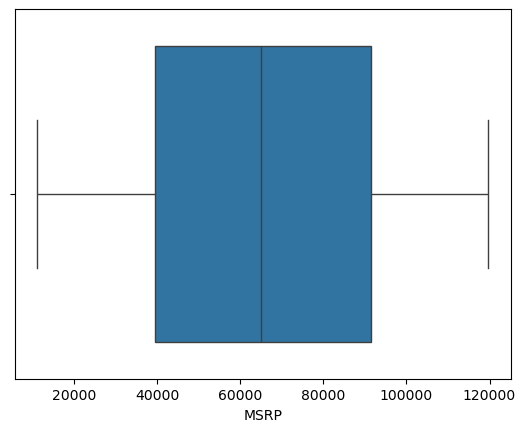

In [108]:
# Boxplot for 'Price' column in dataset.

sns.boxplot(x=df['MSRP'])
plt.show()

### **`Observation:`**<br>
The boxplot shows that the MSRP values range approximately from Rs.10,000 to Rs.120,000. The median car price is around Rs.65,000, while the middle 50 percent of prices lie between Rs.40,000 and Rs.90,000. No outliers are visible, indicating that extreme price values have been removed during data cleaning. The distribution appears to be fairly balanced.

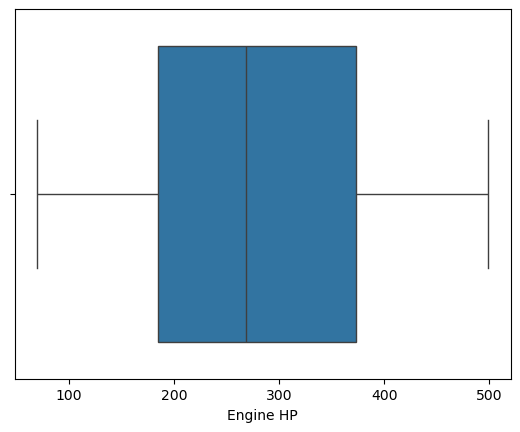

In [107]:
# Boxplot for 'HP' columns in dataset

sns.boxplot(x=df["Engine HP"])
plt.show()


### **`Observation:`**<br>
The boxplot of Engine HP shows that horsepower values range approximately from 70 HP to 500 HP. The median horsepower is around 270–280 HP, while the middle 50% of vehicles have horsepower values between approximately 180 HP and 380 HP. No significant outliers are visible in the plot, indicating that extreme horsepower values have been removed during data cleaning. The distribution appears to be fairly balanced with a moderate spread.

In [74]:
df.dtypes.loc[(df.dtypes == "int64") | (df.dtypes == "float64")]

Year                int64
Engine HP           int64
Engine Cylinders    int64
highway MPG         int64
city mpg            int64
MSRP                int64
dtype: object

## 'Saving the column names of the above output in variable list named 'l'`


In [109]:
l = df.dtypes.loc[(df.dtypes == "int64") | (df.dtypes == "float64")].index.tolist()
print(l)

['Year', 'Engine HP', 'Engine Cylinders', 'highway MPG', 'city mpg', 'MSRP']


## **`Outliers removal techniques - IQR Method`**


In [111]:
Q1 = df[l].quantile(0.25)
Q3 = df[l].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

Year                    7.00
Engine HP             188.25
Engine Cylinders        6.00
highway MPG            14.00
city mpg               13.00
MSRP                52012.75
dtype: float64


In [114]:
# df2 after removing outliers
df2 = df[~((df[l] < (Q1 - 1.5 * IQR)) | (df[l] > (Q3 + 1.5 *
IQR))).any(axis=1)]

In [116]:
print(df.shape)
print(df2.shape)

(300, 10)
(300, 10)


In [117]:
# find unique values and there counts in each column in df using value counts function.

for i in df.columns:
    print("--------------- %s ----------------" % i)
    print(df[i].value_counts())
    print()

--------------- Make ----------------
Make
Ford             40
Honda            39
BMW              34
Toyota           31
Mercedes-Benz    28
Chevrolet        28
Audi             26
Hyundai          26
Kia              25
Nissan           23
Name: count, dtype: int64

--------------- Model ----------------
Model
Convertible    57
Hatchback      55
Coupe          52
Truck          50
SUV            46
Sedan          40
Name: count, dtype: int64

--------------- Year ----------------
Year
2018    27
2016    24
2020    22
2021    21
2023    21
2013    20
2025    19
2024    19
2010    18
2015    18
2014    17
2012    16
2017    15
2011    15
2019    15
2022    13
Name: count, dtype: int64

--------------- Engine HP ----------------
Engine HP
96     5
333    4
195    4
237    4
319    4
      ..
383    1
236    1
254    1
244    1
243    1
Name: count, Length: 211, dtype: int64

--------------- Engine Cylinders ----------------
Engine Cylinders
10    49
8     48
3     45
5     41
12    40


## `Visualising Univariate Distributions`

<Axes: xlabel='Engine HP', ylabel='Count'>

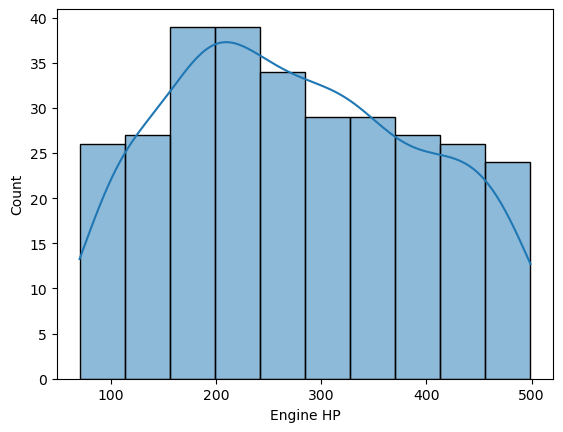

In [85]:
#ploting distplot for variable HP
sns.histplot(df2['Engine HP'], kde=True)


### **`Observation:`**
The histogram shows that the Engine HP values range approximately from 70 HP to 500 HP. Most vehicles have horsepower between 180 HP and 350 HP, indicating that the dataset is dominated by cars with moderate engine power. The distribution is slightly right-skewed, as fewer vehicles have very high horsepower (above 400 HP). The KDE curve confirms that the highest concentration of vehicles lies around 200–250 HP, with the frequency gradually decreasing as horsepower increases.

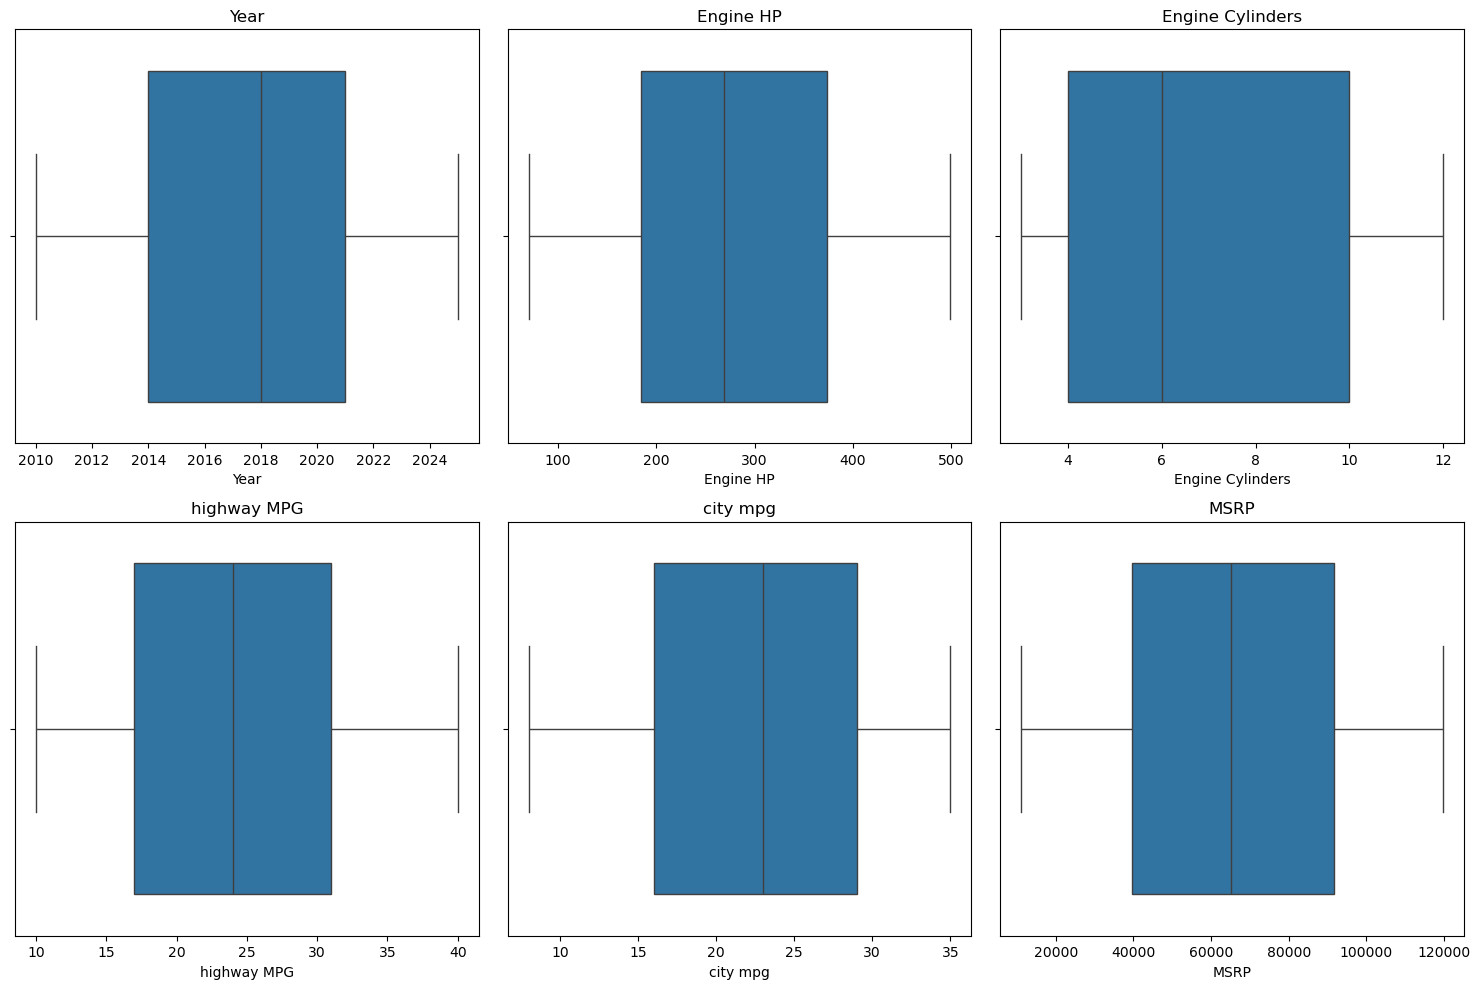

In [86]:
# plotting all the columns present in list l together using subplot of dimention (2,3).

c = 0
plt.figure(figsize=(15,10))

for i in l:
    c = c + 1
    plt.subplot(2, 3, c)
    sns.boxplot(x=df[i])
    plt.title(i)

plt.tight_layout()
plt.show()


## `Bar Chart Plots`


# Plotting a histogram depicting the make in X axis and number of cars in y axis.

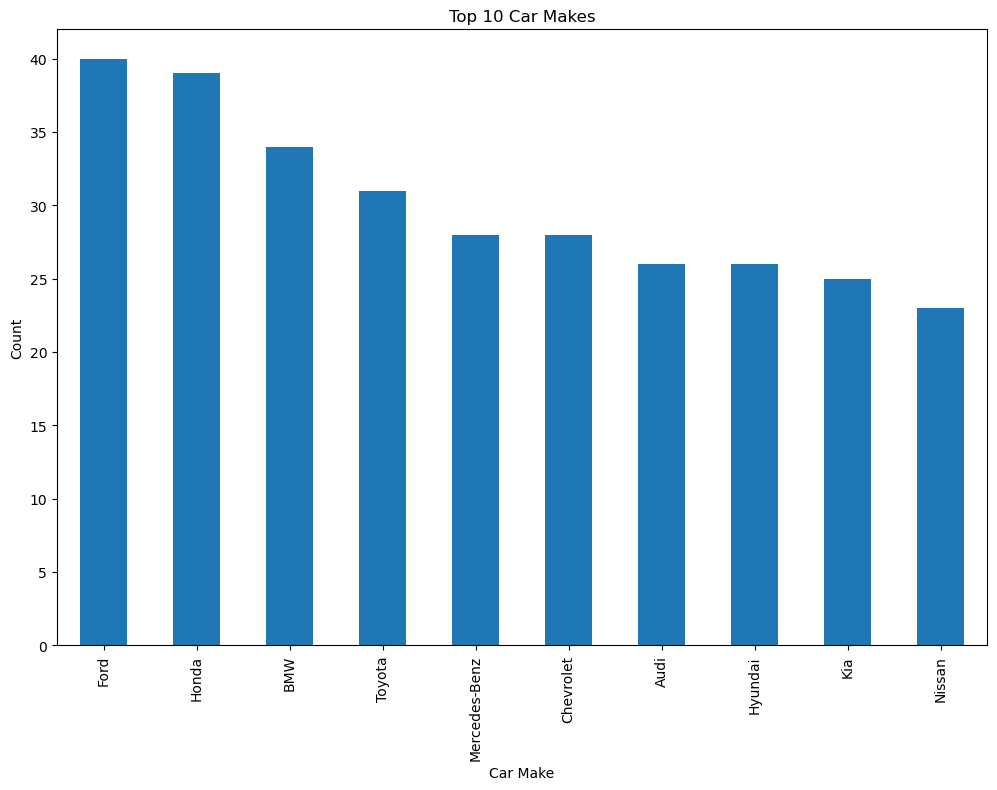

In [87]:
# plt.figure(figsize = (12,8))
# used nlargest and then .plot to get bar plot like below output
# Plot Title, X & Y label

plt.figure(figsize=(12,8))

df["Make"].value_counts().nlargest(10).plot(kind="bar")

plt.title("Top 10 Car Makes")
plt.xlabel("Car Make")
plt.ylabel("Count")

plt.show()



### **`Observation:`**
Ford has the highest number of cars, followed closely by Honda and BMW. Toyota, Mercedes-Benz, and Chevrolet also have a significant presence, while Audi, Hyundai, Kia, and Nissan have comparatively fewer vehicles among the top ten. This indicates that the dataset contains more records for Ford and Honda than for the other manufacturers.

### `Count Plot`
A count plot can be thought of as a histogram across a categorical, instead of quantitative, variable.

 Plotting a countplot for a variable Transmission vertically with hue as Drive mode

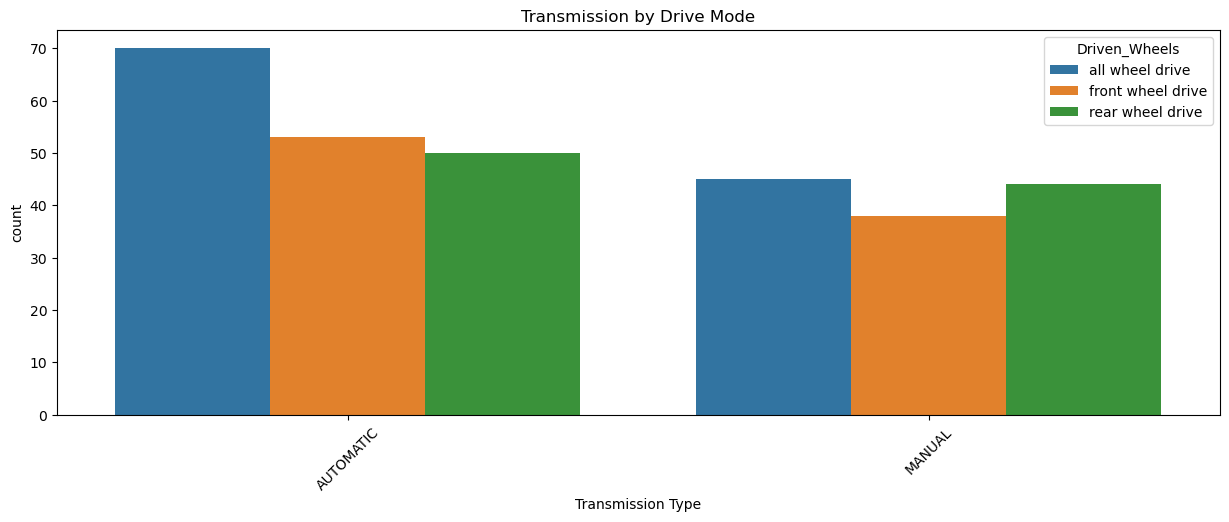

In [93]:
# plt.figure(figsize=(15,5))
# plot countplot on transmission and drive mode

plt.figure(figsize=(15,5))

sns.countplot(x="Transmission Type", hue="Driven_Wheels", data=df)

plt.title("Transmission by Drive Mode")
plt.xticks(rotation=45)
plt.show()


### **`Observation:`**
The count plot shows the distribution of transmission types across different drive modes. Automatic transmission vehicles are more common than manual transmission vehicles in most drive modes. Among the drive modes, All-Wheel Drive (AWD) has the highest number of vehicles, while Front-Wheel Drive (FWD) and Rear-Wheel Drive (RWD) have relatively fewer vehicles. This indicates that automatic transmissions are the dominant choice regardless of drive mode.


# `Visualising Bivariate Distributions`


Bivariate distributions are simply two univariate distributions plotted on x and y axes respectively. They help you observe the relationship between the two variables.




## `Scatter Plots`
Using scatterplot to find the correlation between 'HP' and 'Price' column of the data.


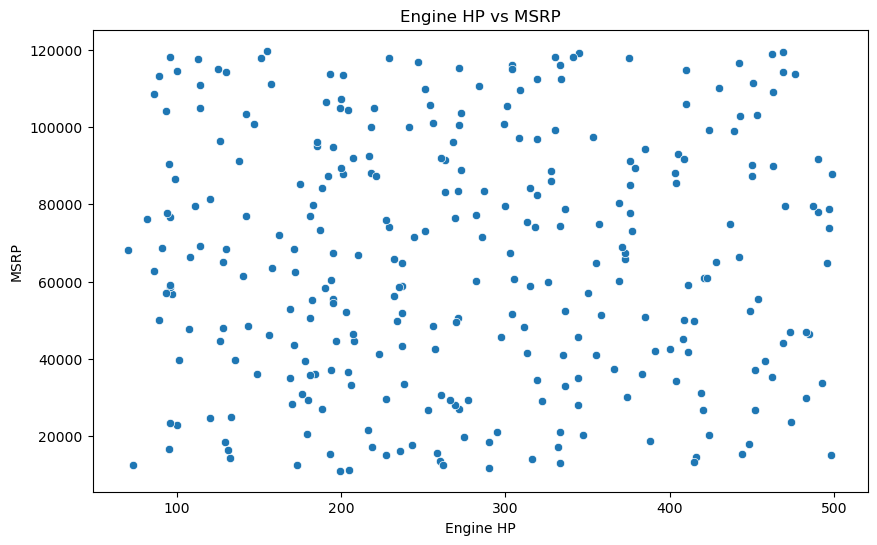

In [121]:
# fig, ax = plt.subplots(figsize=(10,6))

# plot scatterplot on hp and price

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Scatter plot
sns.scatterplot(x="Engine HP", y="MSRP", data=df, ax=ax)

# Title and labels
plt.title("Engine HP vs MSRP")
plt.xlabel("Engine HP")
plt.ylabel("MSRP")
plt.show()

### **`Observation:`**<br>
The scatter plot shows the relationship between Engine Horsepower (HP) and MSRP (car price). The data points are widely scattered, indicating that there is no strong linear relationship between horsepower and price in this dataset. Cars with similar horsepower can have different prices, suggesting that factors such as brand, model, features, engine type, and vehicle category also influence the price.


## `Plotting Aggregated Values across Categories`


### `Bar Plots - Mean, Median and Count Plots`

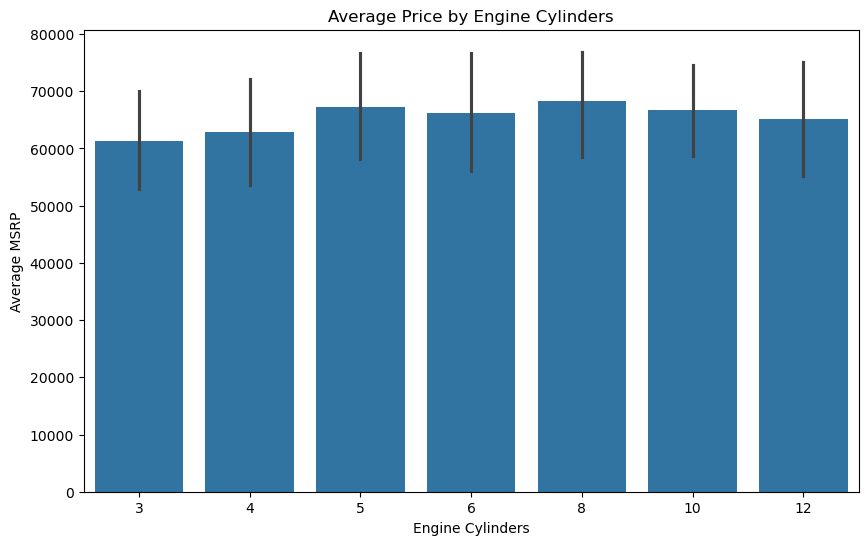

In [120]:
# bar plot with default statistic=mean between Cylinder and Price

plt.figure(figsize=(10,6))
sns.barplot(x="Engine Cylinders", y="MSRP", data=df)
plt.title("Average Price by Engine Cylinders")
plt.xlabel("Engine Cylinders")
plt.ylabel("Average MSRP")
plt.show()

### **`Observation:`**<br>
Cars with 8 cylinders have the highest average MSRP.

Average price generally increases with the number of engine cylinders.

The trend is not perfectly linear, as 10- and 12-cylinder cars have slightly lower average prices than 8-cylinder cars.

Error bars indicate variability in prices within each cylinder group.


##  Transmission sub categories.`

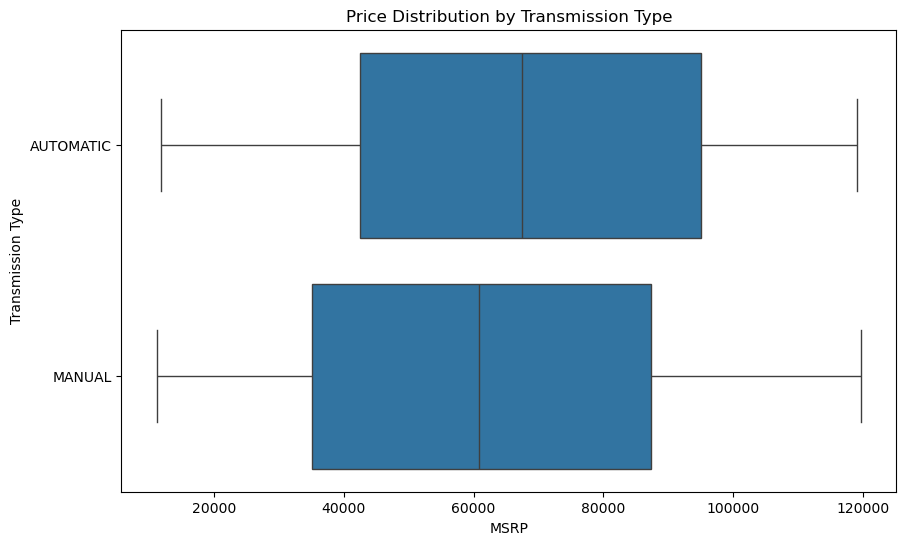

In [97]:
# Plotting categorical variable Transmission across the y-axis
plt.figure(figsize=(10,6))
sns.boxplot(x="MSRP", y="Transmission Type", data=df)
plt.title("Price Distribution by Transmission Type")
plt.xlabel("MSRP")
plt.ylabel("Transmission Type")
plt.show()



# Observation
Automatic transmission cars have a slightly higher median price than manual transmission cars.

The price range is wide for both transmission types.

Automatic cars show slightly greater variation in price.

No major outliers are visible in either category.

# `Multivariate Plots`



In [119]:
#correlation of features of the data

corr = df.corr(numeric_only=True)
print(corr)


                      Year  Engine HP  Engine Cylinders  highway MPG  \
Year              1.000000   0.034283          0.016890    -0.038781   
Engine HP         0.034283   1.000000          0.013085    -0.119811   
Engine Cylinders  0.016890   0.013085          1.000000    -0.064740   
highway MPG      -0.038781  -0.119811         -0.064740     1.000000   
city mpg         -0.072216  -0.084833          0.087778    -0.048091   
MSRP             -0.034565   0.009878          0.038908    -0.007304   

                  city mpg      MSRP  
Year             -0.072216 -0.034565  
Engine HP        -0.084833  0.009878  
Engine Cylinders  0.087778  0.038908  
highway MPG      -0.048091 -0.007304  
city mpg          1.000000  0.043687  
MSRP              0.043687  1.000000  


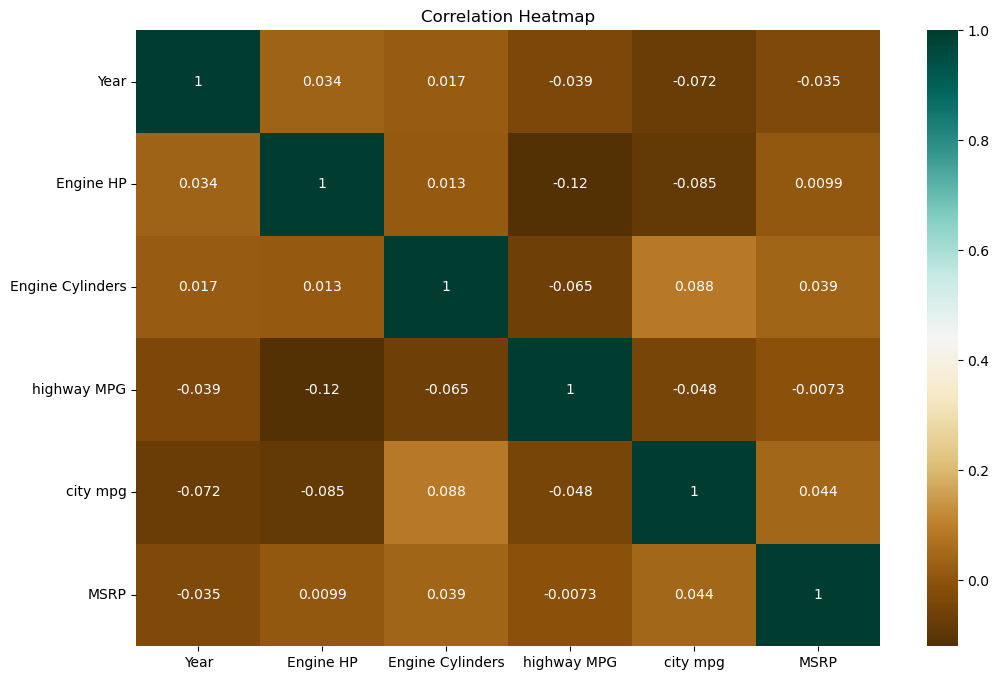

In [118]:
# Using the correlated df, plotted the heatmap
# cmap = 'BrBG', annot = True
# size of graph = (12,8)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="BrBG", annot=True)
plt.title("Correlation Heatmap")
plt.show()

### **`Observation:`**<br>
The correlation heatmap indicates that there are no strong linear relationships among the numerical variables in the dataset. Most correlation coefficients are close to 0, suggesting weak positive or negative correlations. For example, Engine HP has a weak negative correlation with highway MPG (-0.12), indicating that cars with higher horsepower tend to have slightly lower fuel efficiency. Similarly, Year, Engine Cylinders, and city mpg show only weak relationships with the other variables. Overall, the numerical features are not highly correlated, which suggests that each feature contributes different information and there is no significant multicollinearity in the dataset.
